In [39]:
import os
import sys
import numpy as np

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_train import *
from syn_project.utils_color_analysis import *
from syn_project.utils_notebook import *

%matplotlib widget


In [ ]:
# Liste des couples (condition, dataset) à analyser
dataset = "form_50_35_15_cgc_0_20"
experiments = [(f"3mod_basic_s{x}", dataset) for x in range(0, 101)]

checkpoint_epoch = 0
n_samples_test = 1000
split = "test"

all_metrics = {}  # clé : "condition / dataset"

for condition, dataset in experiments:
    with total_silence():
        global_workspace, domain_mods, gw_mod, visual_module, \
            original_data, latent_domains, modules_name = \
            get_modules_data_from_exp(
                experiment_name=condition,
                n_samples_test=n_samples_test,
                split=split,
                checkpoint_epoch=checkpoint_epoch,
            )

    objects = get_objects_from_v_latents(
        latent_domains, gw_mod, global_workspace, modules_name,
        modality_from='attr', modality_through='color',
        modality_main=['attr'], modality_add='color', start_v=False,
    )

    cat = []
    if 'attr' in modules_name:
        cat = original_data['attr'][0]
    if 'cat' in modules_name:
        cat = original_data['cat']

    colors_np = objects['x2']['color'].detach().cpu().numpy()
    cats = cat.argmax(dim=1).detach().cpu().numpy()

    metrics, _ = hue_analysis(
        colors_np, cats, cat_names=CAT_NAMES, value=0.75, saturation_boost=1.8
    )
    label = f"{condition} / {dataset}"
    all_metrics[label] = metrics['per_cat']

/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/torch/nn/modules/module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/torch/nn/modules/module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/torch/nn/modules/module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/torch/nn/modules/module.py:1736: UserWarning

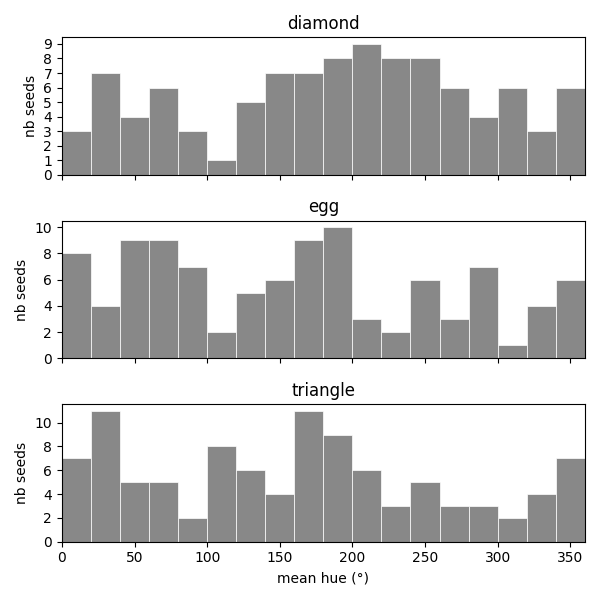

In [41]:
import matplotlib.pyplot as plt
import numpy as np

BIN_SIZE = 20
bins = np.arange(0, 361, BIN_SIZE)
n_cats = len(CAT_NAMES)
fig, axes = plt.subplots(n_cats, 1, figsize=(6, 2 * n_cats), sharex=True)

for ci, ax in enumerate(axes):
    hues = [all_metrics[label][ci]['mean_hue'] for label in all_metrics]
    ax.hist(hues, bins=bins, color='#888888', edgecolor='white', linewidth=0.5)
    ax.set_ylabel("nb seeds")
    ax.set_title(CAT_NAMES[ci], fontsize=12)
    ax.set_xlim(0, 360)
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

axes[-1].set_xlabel("mean hue (°)")
fig.tight_layout()
plt.show()

In [42]:
import numpy as np
from pingouin import circ_rayleigh
from collections import defaultdict

# 1. Collecter les mean_hue par catégorie à travers les seeds
hues_per_cat = defaultdict(list)

for condition, per_cat in all_metrics.items():
    for cat_id, data in per_cat.items():
        hues_per_cat[cat_id].append(data['mean_hue'])

# 2. Test de Rayleigh inter-seeds + statistiques circulaires
def circular_mean(angles_deg):
    rad = np.deg2rad(angles_deg)
    return np.rad2deg(np.arctan2(np.mean(np.sin(rad)), np.mean(np.cos(rad)))) % 360

def circular_std(angles_deg):
    rad = np.deg2rad(angles_deg)
    R = np.sqrt(np.mean(np.sin(rad))**2 + np.mean(np.cos(rad))**2)
    return np.rad2deg(np.sqrt(-2 * np.log(R)))  # Mardia & Jupp

print(f"{'Cat':<12} {'N':>4}  {'circ_mean':>10}  {'circ_std':>9}  {'z':>7}  {'p':>8}  résultat")
print("-" * 72)

n_tests = len(hues_per_cat)
alpha_corrected = 0.05 / n_tests
print(f"Seuil corrigé (Bonferroni) : {alpha_corrected:.4f}\n")

for cat_id in sorted(hues_per_cat.keys()):
    hues = hues_per_cat[cat_id]
    hues_rad = np.deg2rad(hues)
    
    z, p = circ_rayleigh(hues_rad)
    
    cmean = circular_mean(hues)
    cstd  = circular_std(hues)
    name  = CAT_NAMES[cat_id]
    sig   = "✓ convergente" if p < 0.05 else "✗ aléatoire entre seeds"
    
    print(f"{name:<12} {len(hues):>4}  {cmean:>9.1f}°  {cstd:>8.1f}°  {z:>7.3f}  {p:>8.4f}  {sig}")

Cat             N   circ_mean   circ_std        z         p  résultat
------------------------------------------------------------------------
Seuil corrigé (Bonferroni) : 0.0167

diamond       101      224.6°     106.2°    3.262    0.0379  ✓ convergente
egg           101       99.5°     117.1°    1.555    0.2116  ✗ aléatoire entre seeds
triangle      101      113.8°     115.4°    1.744    0.1750  ✗ aléatoire entre seeds


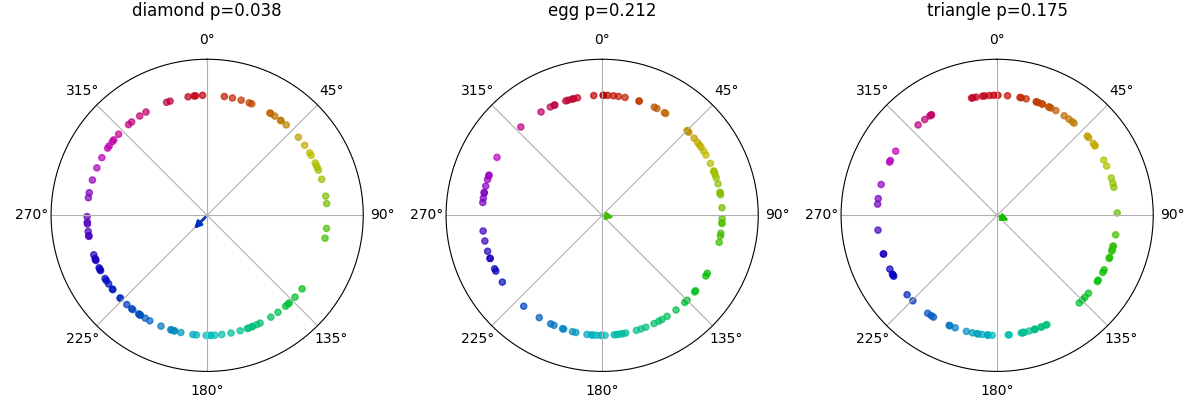

In [43]:
import matplotlib.pyplot as plt
import numpy as np

def hue_to_boosted_rgb(mean_hue_deg, value=0.75, saturation_boost=1.8):
    h = mean_hue_deg / 360.0
    rgb = colorsys.hsv_to_rgb(h, 1.0, 1.0)
    return boost_color(np.array(rgb), value, saturation_boost)

cat_colors = {
    cat_id: hue_to_boosted_rgb(circular_mean(hues_per_cat[cat_id]))
    for cat_id in hues_per_cat
}
fig, axes = plt.subplots(1, 3, figsize=(12, 4), subplot_kw=dict(projection='polar'))

for ax, cat_id in zip(axes, sorted(hues_per_cat.keys())):
    hues = np.array(hues_per_cat[cat_id])
    hues_rad = np.deg2rad(hues)
    name = CAT_NAMES[cat_id]

    # Couleur réelle de chaque point
    point_colors = [hue_to_boosted_rgb(h) for h in hues]

    ax.scatter(hues_rad, np.ones_like(hues_rad),
               alpha=0.7, s=20, color=point_colors)

    # Vecteur moyen — couleur de la teinte moyenne
    cmean = circular_mean(hues)
    cmean_rad = np.deg2rad(cmean)
    R = np.sqrt(np.mean(np.sin(hues_rad))**2 + np.mean(np.cos(hues_rad))**2)
    arrow_color = hue_to_boosted_rgb(cmean)
    ax.annotate("", xy=(cmean_rad, R), xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color=arrow_color, lw=2))

    ax.set_yticks([])
    ax.set_ylim(0, 1.3)
    ax.set_title(f"{name} p={circ_rayleigh(hues_rad)[1]:.3f}",
                 pad=12)
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)

plt.tight_layout()
plt.show()

In [44]:
all_metrics

{'3mod_basic_s0 / form_50_35_15_cgc_0_20': {0: {'name': 'Cat. 0',
   'mean_hue': 213.90047472121114,
   'std_hue': 21.778195666891236},
  1: {'name': 'Cat. 1',
   'mean_hue': 329.4257107357707,
   'std_hue': 9.615097037667049},
  2: {'name': 'Cat. 2',
   'mean_hue': 318.8077595288144,
   'std_hue': 17.975322090498352}},
 '3mod_basic_s1 / form_50_35_15_cgc_0_20': {0: {'name': 'Cat. 0',
   'mean_hue': 218.27370199913682,
   'std_hue': 15.676621618811192},
  1: {'name': 'Cat. 1',
   'mean_hue': 64.36224286090928,
   'std_hue': 13.251400183449908},
  2: {'name': 'Cat. 2',
   'mean_hue': 161.8925758847798,
   'std_hue': 12.288851843485876}},
 '3mod_basic_s2 / form_50_35_15_cgc_0_20': {0: {'name': 'Cat. 0',
   'mean_hue': 222.0099573964086,
   'std_hue': 21.065672147316658},
  1: {'name': 'Cat. 1',
   'mean_hue': 70.13013719624837,
   'std_hue': 13.189803516410935},
  2: {'name': 'Cat. 2',
   'mean_hue': 71.89418592893918,
   'std_hue': 21.442279728207673}},
 '3mod_basic_s3 / form_50_35_15_c